In [1]:
from datetime import datetime, timedelta, UTC
import os
from pathlib import Path

import pandas as pd
from feder import FlightQuery, BoundingBox
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Use test database.

In [2]:
os.environ["FEDER_DATA_DIR"] = str(Path.cwd().parent / 'tests/api/data')

Same time range used for queries in `test_queries.py`.

In [3]:
TSTART = datetime(2025, 5, 22, 18, 15, tzinfo=UTC)
TEND = TSTART + timedelta(minutes=30)

Get all the flights in the test database in the given time range.

In [4]:
query = FlightQuery(TSTART, TEND).time_starts_in()
flights = list(query.run())
print(f"Queried {len(flights)} flights")

Queried 18 flights


Make some boxes: True means we should see flights in the `(min_lon, max_lon, min_lat, max_lat)` bounding box with a spatially crosses query, False means we shouldn't. (Found by plotting on the map below and moving the boundaries to make good test cases.)

In [26]:
boxes = [
    (False, -115, -110, 37, 43),
    (True, -85, -75, 25, 30),
    (True, -110, -70, 35, 45),
    (False, -79, -77, 40, 41.5),
    (False, -102, -100, 21, 31),
    (True, -119, -113, 35, 38)
]

Plot all trajectories and their bounding boxes (blue) and positive (green) and negative (red) test boxes from above.

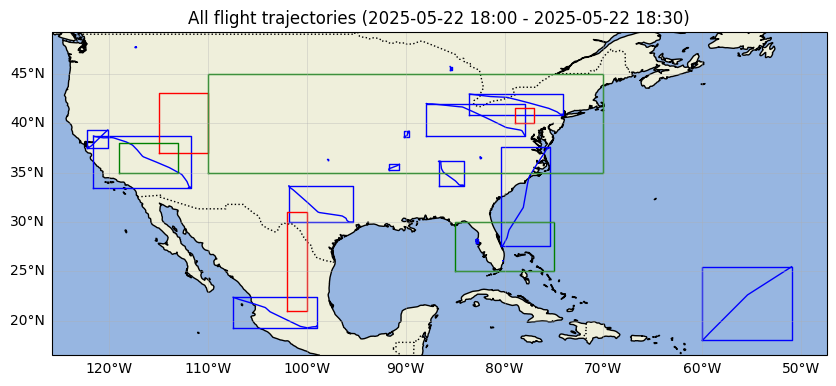

In [27]:
title = "All flight trajectories (2025-05-22 18:00 - 2025-05-22 18:30)"

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("lightcyan")

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

for flight in flights:
    pts = pd.DataFrame(flight.points).sort_values("time")
    ax.plot(
        pts.lon, pts.lat,
        linewidth=1, color="blue",
        transform=ccrs.PlateCarree()
    )
    min_lon = min(pts.lon)
    max_lon = max(pts.lon)
    min_lat = min(pts.lat)
    max_lat = max(pts.lat)
    ax.plot(
        [min_lon, max_lon, max_lon, min_lon, min_lon],
        [min_lat, min_lat, max_lat, max_lat, min_lat],
        color="blue", linewidth=1,
        transform=ccrs.PlateCarree()
    )

for good, min_lon, max_lon, min_lat, max_lat in boxes:
    ax.plot(
        [min_lon, max_lon, max_lon, min_lon, min_lon],
        [min_lat, min_lat, max_lat, max_lat, min_lat],
        color="green" if good else "red", linewidth=1,
        transform=ccrs.PlateCarree()
    )

ax.set_title(title)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.right_labels = False
gl.top_labels = False

plt.show()